### Code for testing different approaches to variable time-shifts 

In [35]:
# --- Cell 1: imports ---

import time
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d

import WDM
from WDM.code.time_delay_filters import time_shift_fast as tsf

# Optional: use LISA-response mismatch utility if available.
try:
    from WDM_LISAresponse.code.utils.utils import wdm_mismatch
except Exception:
    wdm_mismatch = None

print("Imports complete.")
print("WDM module:", WDM.__file__)
print("time_shift_fast module:", tsf.__file__)
print("Using project wdm_mismatch:", wdm_mismatch is not None)

Imports complete.
WDM module: /Users/tomekkinowski/PhD_1/LISA_Response/WDM_GW_wavelets/src/WDM/__init__.py
time_shift_fast module: /Users/tomekkinowski/PhD_1/LISA_Response/WDM_GW_wavelets/src/WDM/code/time_delay_filters/time_shift_fast.py
Using project wdm_mismatch: True


In [36]:
# --- Cell 2: comparison and timing helpers ---

def rel_l2(test, ref):
    test = np.asarray(test)
    ref = np.asarray(ref)

    num = np.linalg.norm(test - ref)
    den = np.linalg.norm(ref)

    return float(num / den) if den != 0 else np.nan


def max_abs(test, ref):
    test = np.asarray(test)
    ref = np.asarray(ref)

    return float(np.max(np.abs(test - ref)))


def norm_ratio(test, ref):
    test = np.asarray(test)
    ref = np.asarray(ref)

    test_norm = np.linalg.norm(test)
    ref_norm = np.linalg.norm(ref)

    return float(test_norm / ref_norm) if ref_norm != 0 else np.nan


def local_overlap_mismatch(test, ref):
    """
    Simple real/complex flattened overlap and mismatch.

    mismatch = 1 - normalized overlap

    Uses the real part of the complex inner product.
    """
    test = np.asarray(test).ravel()
    ref = np.asarray(ref).ravel()

    ref_norm = np.linalg.norm(ref)
    test_norm = np.linalg.norm(test)

    if ref_norm == 0 or test_norm == 0:
        return np.nan, np.nan

    inner = np.vdot(ref, test)
    overlap = float(np.real(inner) / (ref_norm * test_norm))

    # Robust clipping against roundoff.
    overlap_clipped = float(np.clip(overlap, -1.0, 1.0))
    mismatch = float(1.0 - overlap_clipped)

    return overlap_clipped, mismatch


def compare_arrays(test, ref):
    """
    Compare arrays using project wdm_mismatch when available,
    otherwise use a local overlap/mismatch implementation.
    """
    if wdm_mismatch is not None:
        try:
            overlap, mismatch = wdm_mismatch(ref, test)
            overlap = float(overlap)
            mismatch = float(mismatch)
        except Exception:
            overlap, mismatch = local_overlap_mismatch(test, ref)
    else:
        overlap, mismatch = local_overlap_mismatch(test, ref)

    return {
        "rel_l2": rel_l2(test, ref),
        "max_abs": max_abs(test, ref),
        "norm_ratio": norm_ratio(test, ref),
        "overlap": float(overlap),
        "mismatch": float(mismatch),
    }


def time_call(fn, warm=1, repeat=1):
    """
    Simple timing helper.
    """
    for _ in range(max(0, int(warm))):
        _ = fn()

    t0 = time.perf_counter()
    out = None

    for _ in range(max(1, int(repeat))):
        out = fn()

    t1 = time.perf_counter()

    return out, (t1 - t0) / max(1, int(repeat))


def print_table(rows, columns):
    """
    Lightweight plain-text table printer.
    """
    widths = [len(str(col)) for col in columns]

    for row in rows:
        for i, col in enumerate(columns):
            widths[i] = max(widths[i], len(str(row.get(col, ""))))

    header = "  ".join(str(col).ljust(widths[i]) for i, col in enumerate(columns))
    print(header)
    print("-" * len(header))

    for row in rows:
        print("  ".join(str(row.get(col, "")).ljust(widths[i]) for i, col in enumerate(columns)))


print("Comparison and timing helpers ready.")

Comparison and timing helpers ready.


In [167]:
# --- Cell 3: benchmark configuration ---

# -------------------------------------------------------------------
# Fixed physical time-domain problem
# -------------------------------------------------------------------
# These define the actual signal and delay.
# They should NOT change when Nf changes.

dt = 10.0

N_phys = 3_000_000
t_phys = dt * np.arange(N_phys)
T_phys = t_phys[-1] - t_phys[0]

# -------------------------------------------------------------------
# Fixed physical chirplet parameters
# -------------------------------------------------------------------

# Gaussian envelope centre and width.
t0 = 0.5 * T_phys
sigma = 0.12 * T_phys

# Chirplet start/end frequencies.
# These are the actual physical instantaneous frequencies at:
#   t = 0       -> f_start
#   t = T_phys -> approximately f_end
#
# Recommended clean validation band:
#   f_start = 0.003
#   f_end   = 0.010
#
# This avoids both the low-frequency m=0 boundary and the near-Nyquist regime.
f_start = 0.001
f_end = 0.008

fdot = (f_end - f_start) / T_phys

# Backward-compatible names used in later summary/diagnostic cells.
f0 = f_start
f1 = f_end

# -------------------------------------------------------------------
# Fixed physical LISA-like delay
# -------------------------------------------------------------------
#
# Main point:
#   Keep the delay fixed in physical units.
#   Changing Nf changes only the WDM tiling and the row-sampled approximation.
#
# A LISA-like barycentric delay has annual timescale and amplitude of
# a few hundred seconds.

YEAR_SI = 365.25 * 24.0 * 3600.0

tau_offset = 0.0
tau_amp = 500.0
tau_period = YEAR_SI
tau_phase = 0.0

# Optional fast-varying stress test:
# Uncomment to intentionally make the shift vary much faster than LISA-like.
# tau_offset = 0.0
# tau_amp = 180.0
# tau_period = 0.75 * T_phys
# tau_phase = 0.0

# -------------------------------------------------------------------
# WDM configuration
# -------------------------------------------------------------------
# This is the knob you can vary freely.

Nf = 100
q_wdm = 4
L_trunc = 20

# -------------------------------------------------------------------
# WDM time-shift backend
# -------------------------------------------------------------------

BASE_SHIFT_KWARGS = {
    "assembly_backend": "lagfirst_chunked_lagblock",
    "assembly_precision": "complex64",
    "row_chunk_size": 2048,
    "lag_block_size": 16,
    "tl_tp_mode": "interp",
    "tl_tp_interp_points": 32,
    "tl_tp_interp_kind": "linear",
}

# -------------------------------------------------------------------
# Derived diagnostics
# -------------------------------------------------------------------

expected_dT = Nf * dt
expected_dF = 1.0 / (2.0 * Nf * dt)

max_delay_rate = 2.0 * np.pi * abs(tau_amp) / tau_period
max_delay_change_per_wdm_row = max_delay_rate * expected_dT

nyquist = 1.0 / (2.0 * dt)

f_inst_start = f_start
f_inst_mid = f_start + fdot * (0.5 * T_phys)
f_inst_end = f_start + fdot * T_phys

print("Fixed physical problem:")
print("  dt:", dt)
print("  N_phys:", N_phys)
print("  T_phys:", T_phys)
print("  duration_yr:", T_phys / YEAR_SI)
print("  Nyquist:", nyquist)

print("\nChirplet:")
print("  t0:", t0)
print("  sigma:", sigma)
print("  f_start:", f_start)
print("  f_end:", f_end)
print("  fdot:", fdot)
print("  f_inst_start:", f_inst_start)
print("  f_inst_mid:", f_inst_mid)
print("  f_inst_end:", f_inst_end)
print("  f_start > 0:", f_inst_start > 0)
print("  f_end < Nyquist:", f_inst_end < nyquist)

print("\nFixed physical delay:")
print("  tau_offset:", tau_offset)
print("  tau_amp:", tau_amp)
print("  tau_period:", tau_period)
print("  tau_period / T_phys:", tau_period / T_phys)
print("  tau_period / YEAR_SI:", tau_period / YEAR_SI)
print("  tau_phase:", tau_phase)
print("  max |d tau / dt|:", max_delay_rate)

print("\nWDM configuration:")
print("  Nf:", Nf)
print("  q_wdm:", q_wdm)
print("  L_trunc:", L_trunc)
print("  expected dT = Nf * dt:", expected_dT)
print("  expected dF = 1 / (2 Nf dt):", expected_dF)
print("  tau_amp / expected dT:", tau_amp / expected_dT)
print("  max delay change per WDM row:", max_delay_change_per_wdm_row)
print("  f_start / expected dF:", f_start / expected_dF)
print("  f_end / expected dF:", f_end / expected_dF)
print("  bandwidth / expected dF:", (f_end - f_start) / expected_dF)
print("  f_end / Nyquist:", f_end / nyquist)

print("\nBackend kwargs:")
print(BASE_SHIFT_KWARGS)

Fixed physical problem:
  dt: 10.0
  N_phys: 3000000
  T_phys: 29999990.0
  duration_yr: 0.9506423175399904
  Nyquist: 0.05

Chirplet:
  t0: 14999995.0
  sigma: 3599998.8
  f_start: 0.001
  f_end: 0.008
  fdot: 2.3333341111113704e-10
  f_inst_start: 0.001
  f_inst_mid: 0.0045000000000000005
  f_inst_end: 0.008
  f_start > 0: True
  f_end < Nyquist: True

Fixed physical delay:
  tau_offset: 0.0
  tau_amp: 500.0
  tau_period: 31557600.0
  tau_period / T_phys: 1.051920350640117
  tau_period / YEAR_SI: 1.0
  tau_phase: 0.0
  max |d tau / dt|: 9.955106388286159e-05

WDM configuration:
  Nf: 100
  q_wdm: 4
  L_trunc: 20
  expected dT = Nf * dt: 1000.0
  expected dF = 1 / (2 Nf dt): 0.0005
  tau_amp / expected dT: 0.5
  max delay change per WDM row: 0.09955106388286158
  f_start / expected dF: 2.0
  f_end / expected dF: 16.0
  bandwidth / expected dF: 14.0
  f_end / Nyquist: 0.16

Backend kwargs:
{'assembly_backend': 'lagfirst_chunked_lagblock', 'assembly_precision': 'complex64', 'row_chunk_s

# Chirplet test signal and variable time shift

We use a simple complex chirplet as a standalone test signal for the WDM variable time-shift machinery.

The benchmark is designed so that the **physical signal and physical delay are fixed**, while the WDM resolution parameter `Nf` can be changed independently. The only padding applied is right-padding, used to ensure that the padded length satisfies

$$
N_{\rm pad} = N_t N_f,
$$

with \(N_t\) even.

## Test signal

The time-domain signal is a Gaussian-windowed complex sinusoid whose instantaneous frequency grows linearly in time:

$$
h(t) = A(t)e^{i\phi(t)}.
$$

The Gaussian amplitude is

$$
A(t) =
\exp\left[
-\frac{1}{2}
\left(\frac{t-t_0}{\sigma}\right)^2
\right].
$$

We use a start-frequency convention for the chirping phase:

$$
\phi(t)
=
2\pi
\left[
f_{\rm start} t
+
\frac{1}{2}\dot f t^2
\right].
$$

The instantaneous frequency is therefore

$$
f_{\rm inst}(t)
=
\frac{1}{2\pi}\frac{d\phi}{dt}
=
f_{\rm start} + \dot f t.
$$

The chirp rate is chosen so that the signal starts at \(f_{\rm start}\) and ends near \(f_{\rm end}\):

$$
\dot f
=
\frac{f_{\rm end}-f_{\rm start}}{T_{\rm phys}}.
$$

This avoids the earlier ambiguity where \(f_0\) was interpreted as the frequency at the Gaussian centre, which could make the instantaneous frequency negative near the beginning of the signal.

## Plus and cross channels

The complex chirplet is split into two real channels:

$$
h_+(t) = \operatorname{Re}[h(t)],
\qquad
h_\times(t) = \operatorname{Im}[h(t)].
$$

This mimics the use of two real waveform polarizations while keeping the toy model analytically controlled.

## Variable time shift

We apply a fixed physical, LISA-like sinusoidal delay,

$$
\tau(t)
=
\tau_{\rm offset}
+
\tau_{\rm amp}
\sin\left(
\frac{2\pi t}{T_\tau}
+
\phi_\tau
\right).
$$

For the main validation case, \(T_\tau\) is chosen to be one sidereal/year-like timescale and \(\tau_{\rm amp}\) is of order a few hundred seconds. The relevant smoothness diagnostic is the maximum delay change over one WDM time row,

$$
\max |\dot{\tau}| \, \Delta T,
\qquad
\Delta T = N_f \, \delta t.
$$

For a sinusoidal delay,

$$
\max |\dot{\tau}| \, \Delta T
=
\frac{2\pi \tau_{\rm amp}}{T_\tau}\Delta T.
$$

This quantity should be small for a LISA-like slowly varying delay.

## Time-domain reference

Because the chirplet is analytic, the primary time-domain reference is built by evaluating the chirplet directly at shifted times:

$$
h_{\rm ref}(t)
=
h(t + \tau(t)).
$$

Samples whose shifted time lies outside the original physical interval are set to zero.

The sign convention used in the notebook is

$$
\text{TD reference: } h(t+\tau(t)),
\qquad
\text{WDM input shift: } -\tau(t).
$$

Linear interpolation can be kept as a diagnostic, but it is not the primary reference because it introduces noticeable error for chirplets with only a few samples per cycle.

## WDM-domain test

The WDM-domain test applies the variable time shift directly to the WDM coefficients using `wdm_time_shift_variable`.

Accuracy is assessed by transforming the analytic time-domain reference into WDM space and comparing it with the WDM-shifted result. Comparisons are made on the original physical WDM rows only, excluding the right-padded region and dropping the \(m=0\) frequency bin.

The diagnostics include relative \(L^2\), norm ratio, overlap, mismatch, and maximum absolute coefficient residual.

This notebook is intentionally independent of the LISA response pipeline. It tests only the core variable time-shift operation on a controlled signal with a known analytic time-domain reference.

In [168]:
# --- Cell 4: fixed two-channel chirplet with right padding only ---

def make_complex_chirplet(t, *, t0, sigma, f_start, fdot):
    """
    Complex Gaussian-windowed chirplet with start-frequency convention.

    Envelope:
        A(t) = exp[-0.5 ((t - t0) / sigma)^2]

    Phase:
        phi(t) = 2π [ f_start * t + 0.5 * fdot * t^2 ]

    Therefore:
        f_inst(t) = f_start + fdot * t

    So f_start is the instantaneous frequency at t = 0.
    """
    t = np.asarray(t)

    amp = np.exp(-0.5 * ((t - t0) / sigma) ** 2)
    phase = 2.0 * np.pi * (f_start * t + 0.5 * fdot * t**2)

    return amp * np.exp(1j * phase)


def make_variable_delay(
    t,
    *,
    tau_amp,
    tau_period,
    tau_offset=0.0,
    tau_phase=0.0,
):
    """
    LISA-like sinusoidal delay:

        tau(t) = tau_offset + tau_amp sin(2π t / tau_period + tau_phase)
    """
    t = np.asarray(t)

    return tau_offset + tau_amp * np.sin(
        2.0 * np.pi * t / tau_period + tau_phase
    )


def right_pad_to_even_wdm_nt(x_phys, *, Nf):
    """
    Right-pad a physical time series so that:

        N_pad = Nt * Nf
        Nt is even

    Equivalently, N_pad is the smallest multiple of 2*Nf
    greater than or equal to N_phys.
    """
    x_phys = np.asarray(x_phys)
    n_phys = len(x_phys)

    block = 2 * int(Nf)
    n_pad = int(np.ceil(n_phys / block) * block)

    pad_right = n_pad - n_phys
    x_pad = np.pad(x_phys, (0, pad_right), mode="constant")

    pad_info = {
        "n_phys": int(n_phys),
        "n_pad": int(n_pad),
        "pad_left": 0,
        "pad_right": int(pad_right),
        "block": int(block),
        "Nt_expected": int(n_pad // int(Nf)),
    }

    return x_pad, pad_info


# -------------------------------------------------------------------
# Build fixed physical signal on the physical grid
# -------------------------------------------------------------------

h_complex_phys = make_complex_chirplet(
    t_phys,
    t0=t0,
    sigma=sigma,
    f_start=f_start,
    fdot=fdot,
)

h_plus_phys = np.real(h_complex_phys)
h_cross_phys = np.imag(h_complex_phys)

tau_phys = make_variable_delay(
    t_phys,
    tau_amp=tau_amp,
    tau_period=tau_period,
    tau_offset=tau_offset,
    tau_phase=tau_phase,
)

f_inst_phys = f_start + fdot * t_phys

# -------------------------------------------------------------------
# Right-pad plus/cross channels to WDM-compatible length
# -------------------------------------------------------------------

h_plus_td, pad_info = right_pad_to_even_wdm_nt(
    h_plus_phys,
    Nf=Nf,
)

h_cross_td, pad_info_cross = right_pad_to_even_wdm_nt(
    h_cross_phys,
    Nf=Nf,
)

if pad_info_cross != pad_info:
    raise RuntimeError("plus/cross padding info mismatch.")

N = pad_info["n_pad"]
t = dt * np.arange(N)

# Delay and instantaneous-frequency diagnostics on padded grid.
# Signal is zero after N_phys; delay is still defined on the full padded grid.
tau_td = make_variable_delay(
    t,
    tau_amp=tau_amp,
    tau_period=tau_period,
    tau_offset=tau_offset,
    tau_phase=tau_phase,
)

f_inst = f_start + fdot * t

print("Fixed physical two-channel chirplet built and right-padded.")
print("pad_info:", pad_info)

print("\nShapes:")
print("  h_complex_phys:", h_complex_phys.shape)
print("  h_plus_phys:", h_plus_phys.shape)
print("  h_cross_phys:", h_cross_phys.shape)
print("  h_plus_td padded:", h_plus_td.shape)
print("  h_cross_td padded:", h_cross_td.shape)
print("  t padded:", t.shape)

print("\nPadded time range:")
print("  t[0]:", t[0])
print("  t[-1]:", t[-1])
print("  physical start/end:", t_phys[0], t_phys[-1])

print("\nPadding:")
print("  pad_right samples:", pad_info["pad_right"])
print("  pad_right time:", pad_info["pad_right"] * dt)
print("  Nt_expected:", pad_info["Nt_expected"])
print("  Nt_expected even:", pad_info["Nt_expected"] % 2 == 0)

print("\nNorms:")
print("  ||h_plus_phys||:", np.linalg.norm(h_plus_phys))
print("  ||h_cross_phys||:", np.linalg.norm(h_cross_phys))
print("  ||h_plus_td padded||:", np.linalg.norm(h_plus_td))
print("  ||h_cross_td padded||:", np.linalg.norm(h_cross_td))

print("\nDelay:")
print("  tau_phys min/max:", float(np.min(tau_phys)), float(np.max(tau_phys)))
print("  tau_td padded min/max:", float(np.min(tau_td)), float(np.max(tau_td)))

print("\nInstantaneous frequency:")
print("  physical min:", float(np.min(f_inst_phys)))
print("  physical max:", float(np.max(f_inst_phys)))
print("  padded min:", float(np.min(f_inst)))
print("  padded max:", float(np.max(f_inst)))
print("  Nyquist:", nyquist)

if np.min(f_inst_phys) <= 0:
    print("WARNING: physical instantaneous frequency is non-positive.")
else:
    print("Physical instantaneous frequency is positive.")

if np.max(f_inst_phys) >= nyquist:
    print("WARNING: physical instantaneous frequency reaches or exceeds Nyquist.")
else:
    print("Physical frequency range is safely below Nyquist.")

Fixed physical two-channel chirplet built and right-padded.
pad_info: {'n_phys': 3000000, 'n_pad': 3000000, 'pad_left': 0, 'pad_right': 0, 'block': 200, 'Nt_expected': 30000}

Shapes:
  h_complex_phys: (3000000,)
  h_plus_phys: (3000000,)
  h_cross_phys: (3000000,)
  h_plus_td padded: (3000000,)
  h_cross_td padded: (3000000,)
  t padded: (3000000,)

Padded time range:
  t[0]: 0.0
  t[-1]: 29999990.0
  physical start/end: 0.0 29999990.0

Padding:
  pad_right samples: 0
  pad_right time: 0.0
  Nt_expected: 30000
  Nt_expected even: True

Norms:
  ||h_plus_phys||: 564.837663052458
  ||h_cross_phys||: 564.8376630524705
  ||h_plus_td padded||: 564.837663052458
  ||h_cross_td padded||: 564.8376630524705

Delay:
  tau_phys min/max: -500.0 500.0
  tau_td padded min/max: -500.0 500.0

Instantaneous frequency:
  physical min: 0.001
  physical max: 0.008
  padded min: 0.001
  padded max: 0.008
  Nyquist: 0.05
Physical instantaneous frequency is positive.
Physical frequency range is safely below 

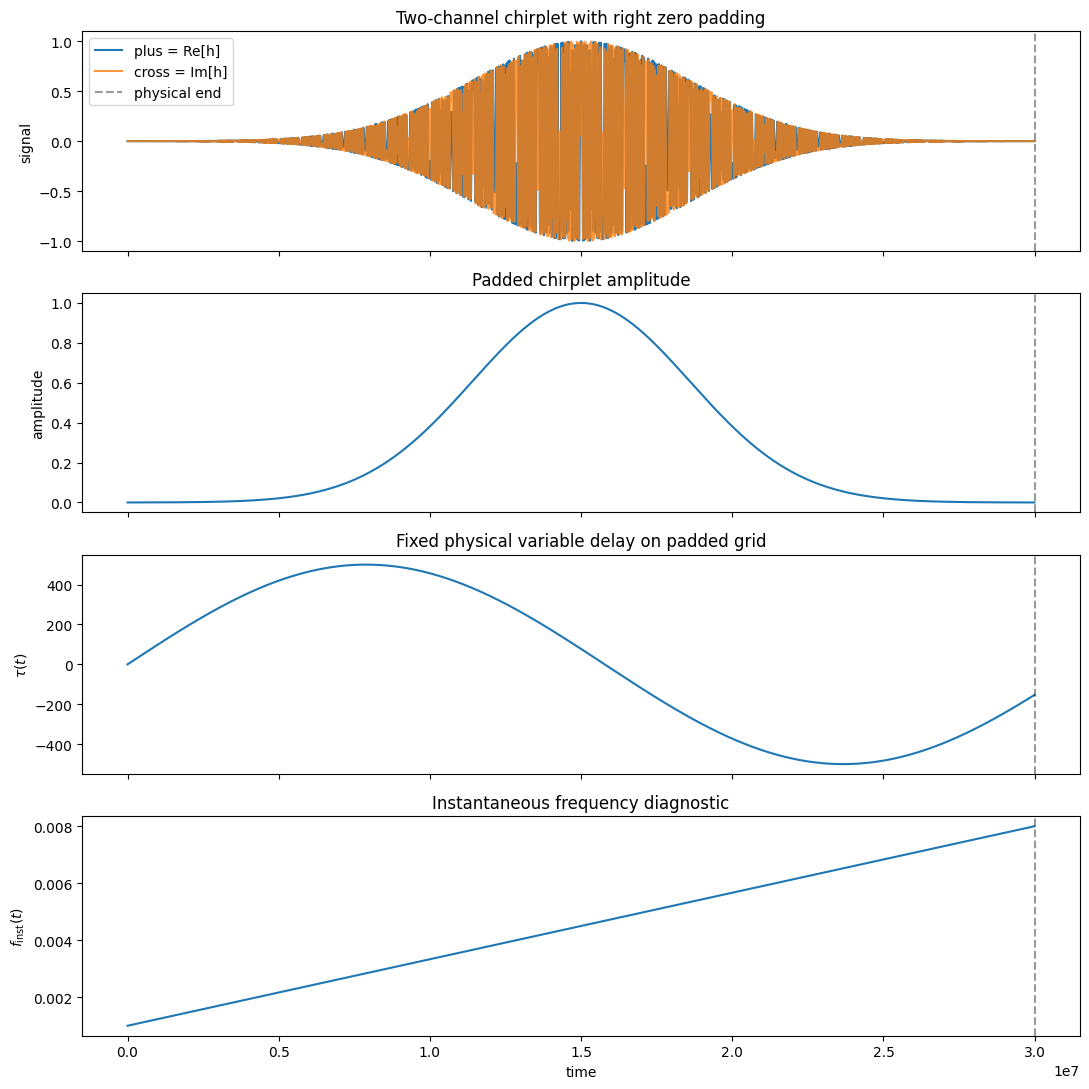

In [169]:
# --- Cell 5: quick diagnostic plots ---

plot_stride = max(1, N // 5000)

fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

axes[0].plot(t[::plot_stride], h_plus_td[::plot_stride], label="plus = Re[h]")
axes[0].plot(t[::plot_stride], h_cross_td[::plot_stride], label="cross = Im[h]", alpha=0.8)
axes[0].axvline(t_phys[-1], color="k", linestyle="--", alpha=0.4, label="physical end")
axes[0].set_ylabel("signal")
axes[0].set_title("Two-channel chirplet with right zero padding")
axes[0].legend()

axes[1].plot(
    t[::plot_stride],
    np.sqrt(h_plus_td[::plot_stride]**2 + h_cross_td[::plot_stride]**2),
)
axes[1].axvline(t_phys[-1], color="k", linestyle="--", alpha=0.4)
axes[1].set_ylabel("amplitude")
axes[1].set_title("Padded chirplet amplitude")

axes[2].plot(t[::plot_stride], tau_td[::plot_stride])
axes[2].axvline(t_phys[-1], color="k", linestyle="--", alpha=0.4)
axes[2].set_ylabel(r"$\tau(t)$")
axes[2].set_title("Fixed physical variable delay on padded grid")

axes[3].plot(t[::plot_stride], f_inst[::plot_stride])
axes[3].axvline(t_phys[-1], color="k", linestyle="--", alpha=0.4)
axes[3].set_xlabel("time")
axes[3].set_ylabel(r"$f_{\rm inst}(t)$")
axes[3].set_title("Instantaneous frequency diagnostic")

plt.tight_layout()
plt.show()

In [170]:
# --- Cell 6: two-channel analytic time-domain shift reference on padded grid ---

def analytic_chirplet_on_physical_support(sample_t):
    """
    Evaluate the complex chirplet analytically at arbitrary sample times,
    but set values outside the original physical interval to zero.

    This is the primary reference for the toy model. It avoids the amplitude
    and phase error that linear interpolation can introduce when the chirplet
    has only a few samples per cycle.
    """
    sample_t = np.asarray(sample_t)

    h = make_complex_chirplet(
        sample_t,
        t0=t0,
        sigma=sigma,
        f_start=f_start,
        fdot=fdot,
    )

    inside = (sample_t >= t_phys[0]) & (sample_t <= t_phys[-1])

    return np.where(inside, h, 0.0 + 0.0j)


def analytic_time_domain_variable_shift_reference(t, tau, *, sign=-1):
    """
    Analytic time-domain variable-shift reference.

    sign=-1 gives:
        h_ref(t) = h(t - tau(t))

    sign=+1 gives:
        h_ref(t) = h(t + tau(t))

    Values sampled outside the original physical interval are set to zero.
    """
    t = np.asarray(t)
    tau = np.asarray(tau)

    sample_t = t + sign * tau
    h_shift_complex = analytic_chirplet_on_physical_support(sample_t)

    return np.real(h_shift_complex), np.imag(h_shift_complex)


def interpolation_time_domain_variable_shift_reference(h, t, tau, *, sign=-1):
    """
    Linear-interpolation reference kept only as a diagnostic.

    This is not the primary reference because it can be inaccurate for
    chirplets with only a few samples per cycle.
    """
    h = np.asarray(h)
    t = np.asarray(t)
    tau = np.asarray(tau)

    sample_t = t + sign * tau

    interp = interp1d(
        t,
        h,
        kind="linear",
        bounds_error=False,
        fill_value=0.0,
        assume_sorted=True,
    )

    return interp(sample_t)


# -------------------------------------------------------------------
# Analytic references for both sign conventions
# -------------------------------------------------------------------

h_plus_shift_td_minus, h_cross_shift_td_minus = analytic_time_domain_variable_shift_reference(
    t,
    tau_td,
    sign=-1,
)

h_plus_shift_td_plus, h_cross_shift_td_plus = analytic_time_domain_variable_shift_reference(
    t,
    tau_td,
    sign=+1,
)


# -------------------------------------------------------------------
# Optional interpolation references for diagnostics
# -------------------------------------------------------------------

h_plus_shift_interp_minus = interpolation_time_domain_variable_shift_reference(
    h_plus_td,
    t,
    tau_td,
    sign=-1,
)

h_cross_shift_interp_minus = interpolation_time_domain_variable_shift_reference(
    h_cross_td,
    t,
    tau_td,
    sign=-1,
)

h_plus_shift_interp_plus = interpolation_time_domain_variable_shift_reference(
    h_plus_td,
    t,
    tau_td,
    sign=+1,
)

h_cross_shift_interp_plus = interpolation_time_domain_variable_shift_reference(
    h_cross_td,
    t,
    tau_td,
    sign=+1,
)


# -------------------------------------------------------------------
# Diagnostics
# -------------------------------------------------------------------

print("Two-channel analytic time-domain references built on padded grid.")

print("\nShapes:")
print("  h_plus_shift_td_minus:", h_plus_shift_td_minus.shape)
print("  h_cross_shift_td_minus:", h_cross_shift_td_minus.shape)
print("  h_plus_shift_td_plus:", h_plus_shift_td_plus.shape)
print("  h_cross_shift_td_plus:", h_cross_shift_td_plus.shape)

print("\nNorms, analytic references:")
print("  plus minus:", np.linalg.norm(h_plus_shift_td_minus))
print("  cross minus:", np.linalg.norm(h_cross_shift_td_minus))
print("  plus plus:", np.linalg.norm(h_plus_shift_td_plus))
print("  cross plus:", np.linalg.norm(h_cross_shift_td_plus))

print("\nInterpolation-vs-analytic diagnostic:")
print("  plus minus rel_l2:", rel_l2(h_plus_shift_interp_minus, h_plus_shift_td_minus))
print("  cross minus rel_l2:", rel_l2(h_cross_shift_interp_minus, h_cross_shift_td_minus))
print("  plus plus rel_l2:", rel_l2(h_plus_shift_interp_plus, h_plus_shift_td_plus))
print("  cross plus rel_l2:", rel_l2(h_cross_shift_interp_plus, h_cross_shift_td_plus))

print("\nOut-of-range diagnostic on padded grid:")
sample_t_minus = t - tau_td
sample_t_plus = t + tau_td

frac_oor_minus = np.mean(
    (sample_t_minus < t_phys[0])
    | (sample_t_minus > t_phys[-1])
)

frac_oor_plus = np.mean(
    (sample_t_plus < t_phys[0])
    | (sample_t_plus > t_phys[-1])
)

print("  fraction outside physical interval for h(t - tau):", frac_oor_minus)
print("  fraction outside physical interval for h(t + tau):", frac_oor_plus)

Two-channel analytic time-domain references built on padded grid.

Shapes:
  h_plus_shift_td_minus: (3000000,)
  h_cross_shift_td_minus: (3000000,)
  h_plus_shift_td_plus: (3000000,)
  h_cross_shift_td_plus: (3000000,)

Norms, analytic references:
  plus minus: 564.8132344776371
  cross minus: 564.8132344776692
  plus plus: 564.8620937595539
  cross plus: 564.862093759559

Interpolation-vs-analytic diagnostic:
  plus minus rel_l2: 0.00765336081052453
  cross minus rel_l2: 0.007653360810588401
  plus plus rel_l2: 0.007653366226182095
  cross plus rel_l2: 0.007653366226040977

Out-of-range diagnostic on padded grid:
  fraction outside physical interval for h(t - tau): 5.333333333333334e-06
  fraction outside physical interval for h(t + tau): 0.0


In [171]:
# --- Cell 7: WDM transform and two-channel TD-reference WDM arrays ---

wdm = WDM.WDM.WDM_transform(
    dt=dt,
    Nf=Nf,
    N=N,
    q=q_wdm,
    calc_m0=True,
    d=4,
    A_frac=0.25,
)

print("WDM object:")
print("  Nt:", wdm.Nt)
print("  Nf:", wdm.Nf)
print("  N:", wdm.N)
print("  dT:", wdm.dT)
print("  dF:", wdm.dF)

print("\nTransforming plus/cross original and TD-shifted references to WDM...")

h_plus_wdm, h_plus_wdm_time_s = time_call(
    lambda: wdm.dwt(h_plus_td),
    warm=0,
    repeat=1,
)

h_cross_wdm, h_cross_wdm_time_s = time_call(
    lambda: wdm.dwt(h_cross_td),
    warm=0,
    repeat=1,
)

h_plus_shift_minus_wdm_ref, h_plus_shift_minus_wdm_time_s = time_call(
    lambda: wdm.dwt(h_plus_shift_td_minus),
    warm=0,
    repeat=1,
)

h_cross_shift_minus_wdm_ref, h_cross_shift_minus_wdm_time_s = time_call(
    lambda: wdm.dwt(h_cross_shift_td_minus),
    warm=0,
    repeat=1,
)

h_plus_shift_plus_wdm_ref, h_plus_shift_plus_wdm_time_s = time_call(
    lambda: wdm.dwt(h_plus_shift_td_plus),
    warm=0,
    repeat=1,
)

h_cross_shift_plus_wdm_ref, h_cross_shift_plus_wdm_time_s = time_call(
    lambda: wdm.dwt(h_cross_shift_td_plus),
    warm=0,
    repeat=1,
)

print("Shapes:")
print("  h_plus_wdm:", h_plus_wdm.shape)
print("  h_cross_wdm:", h_cross_wdm.shape)
print("  h_plus_shift_minus_wdm_ref:", h_plus_shift_minus_wdm_ref.shape)
print("  h_cross_shift_minus_wdm_ref:", h_cross_shift_minus_wdm_ref.shape)
print("  h_plus_shift_plus_wdm_ref:", h_plus_shift_plus_wdm_ref.shape)
print("  h_cross_shift_plus_wdm_ref:", h_cross_shift_plus_wdm_ref.shape)

print("\nDWT timings:")
print("  plus original_s:", h_plus_wdm_time_s)
print("  cross original_s:", h_cross_wdm_time_s)
print("  plus minus reference_s:", h_plus_shift_minus_wdm_time_s)
print("  cross minus reference_s:", h_cross_shift_minus_wdm_time_s)
print("  plus plus reference_s:", h_plus_shift_plus_wdm_time_s)
print("  cross plus reference_s:", h_cross_shift_plus_wdm_time_s)

print("\nNorms:")
print("  ||h_plus_wdm||:", np.linalg.norm(h_plus_wdm))
print("  ||h_cross_wdm||:", np.linalg.norm(h_cross_wdm))
print("  ||plus minus ref||:", np.linalg.norm(h_plus_shift_minus_wdm_ref))
print("  ||cross minus ref||:", np.linalg.norm(h_cross_shift_minus_wdm_ref))
print("  ||plus plus ref||:", np.linalg.norm(h_plus_shift_plus_wdm_ref))
print("  ||cross plus ref||:", np.linalg.norm(h_cross_shift_plus_wdm_ref))

WDM object:
  Nt: 30000
  Nf: 100
  N: 3000000
  dT: 1000.0
  dF: 0.0005

Transforming plus/cross original and TD-shifted references to WDM...
Shapes:
  h_plus_wdm: (30000, 100)
  h_cross_wdm: (30000, 100)
  h_plus_shift_minus_wdm_ref: (30000, 100)
  h_cross_shift_minus_wdm_ref: (30000, 100)
  h_plus_shift_plus_wdm_ref: (30000, 100)
  h_cross_shift_plus_wdm_ref: (30000, 100)

DWT timings:
  plus original_s: 2.365259917001822
  cross original_s: 1.6375669580011163
  plus minus reference_s: 0.4362090830109082
  cross minus reference_s: 0.2950985419884091
  plus plus reference_s: 0.21144854099838994
  cross plus reference_s: 0.5040170410065912

Norms:
  ||h_plus_wdm||: 1786.1751769835573
  ||h_cross_wdm||: 1786.1751788414076
  ||plus minus ref||: 1786.0979273124055
  ||cross minus ref||: 1786.0979279579801
  ||plus plus ref||: 1786.2524360810316
  ||cross plus ref||: 1786.252433784418


WDM delay grid built.
WDM_ROW_OFFSET: 0.0
t_wdm shape: (30000,)
tau_wdm shape: (30000,)

WDM timing:
  wdm.Nt: 30000
  wdm.Nf: 100
  wdm.dT: 1000.0
  wdm.dF: 0.0005
  t_wdm min/max: 0.0 29999000.0

Delay diagnostics:
  tau_wdm min/max: -499.99999960358343 499.99999841433373
  tau_amp: 500.0
  tau_offset: 0.0
  tau_amp / wdm.dT: 0.5
  tau_period / wdm.dT: 31557.6
  max |d tau / dt|: 9.955106388286159e-05
  max delay change per WDM row: 0.09955106388286158


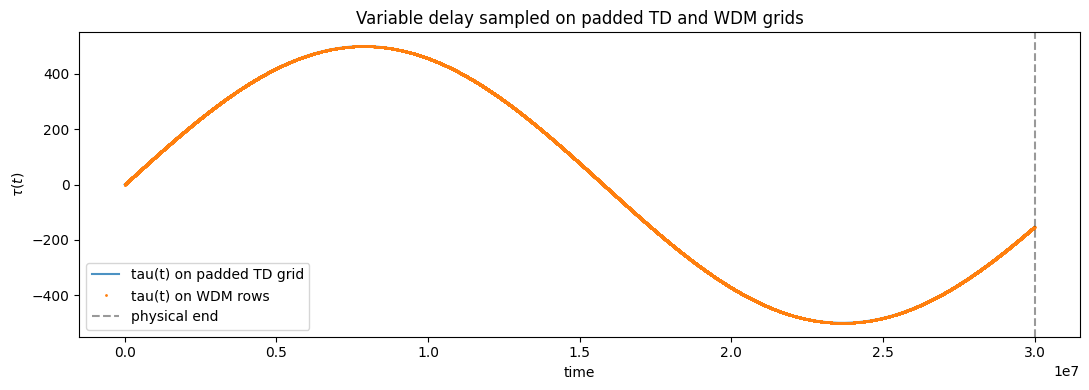

In [172]:
# --- Cell 8: delay sampled on the WDM time grid ---

# WDM row n corresponds to sample index n*Nf.
# With right-padding only, the padded time grid starts at t=0.
#
# The implementation/theory uses t_p = p ΔT, so row_offset=0.0.
WDM_ROW_OFFSET = 0.0

t_wdm = (np.arange(wdm.Nt) + WDM_ROW_OFFSET) * wdm.dT

tau_wdm = make_variable_delay(
    t_wdm,
    tau_amp=tau_amp,
    tau_period=tau_period,
    tau_offset=tau_offset,
    tau_phase=tau_phase,
)

max_delay_rate = 2.0 * np.pi * abs(tau_amp) / tau_period
max_delay_change_per_wdm_row = max_delay_rate * wdm.dT

print("WDM delay grid built.")
print("WDM_ROW_OFFSET:", WDM_ROW_OFFSET)
print("t_wdm shape:", t_wdm.shape)
print("tau_wdm shape:", tau_wdm.shape)

print("\nWDM timing:")
print("  wdm.Nt:", wdm.Nt)
print("  wdm.Nf:", wdm.Nf)
print("  wdm.dT:", wdm.dT)
print("  wdm.dF:", wdm.dF)
print("  t_wdm min/max:", float(np.min(t_wdm)), float(np.max(t_wdm)))

print("\nDelay diagnostics:")
print("  tau_wdm min/max:", float(np.min(tau_wdm)), float(np.max(tau_wdm)))
print("  tau_amp:", tau_amp)
print("  tau_offset:", tau_offset)
print("  tau_amp / wdm.dT:", tau_amp / wdm.dT)
print("  tau_period / wdm.dT:", tau_period / wdm.dT)
print("  max |d tau / dt|:", max_delay_rate)
print("  max delay change per WDM row:", max_delay_change_per_wdm_row)

plt.figure(figsize=(11, 4))
plt.plot(t[::plot_stride], tau_td[::plot_stride], label="tau(t) on padded TD grid", alpha=0.8)
plt.plot(t_wdm, tau_wdm, ".", markersize=2, label="tau(t) on WDM rows")
plt.axvline(t_phys[-1], color="k", linestyle="--", alpha=0.4, label="physical end")
plt.xlabel("time")
plt.ylabel(r"$\tau(t)$")
plt.title("Variable delay sampled on padded TD and WDM grids")
plt.legend()
plt.tight_layout()
plt.show()

In [173]:
# --- Cell 9: WDM variable time shift for plus/cross, fixed sign convention ---

# Fixed convention established from sign tests:
#   WDM input -tau_wdm matches analytic TD reference h(t + tau).
TD_SIGN = +1
WDM_TAU_SIGN = -1.0

print("Using fixed sign convention:")
print("  TD_SIGN:", TD_SIGN, "meaning TD reference h(t + tau)")
print("  WDM_TAU_SIGN:", WDM_TAU_SIGN, "meaning WDM shift input -tau_wdm")


def run_wdm_shift_channel(w_channel, tau_sign, kwargs):
    """
    Apply WDM variable time shift to one real channel's WDM coefficients.
    """
    return tsf.wdm_time_shift_variable(
        wdm,
        w_channel,
        tau_sign * tau_wdm,
        Nf=wdm.Nf,
        delta_mode="target",
        L_trunc=L_trunc,
        **kwargs,
    )


def run_plus_fixed():
    return run_wdm_shift_channel(
        h_plus_wdm,
        WDM_TAU_SIGN,
        BASE_SHIFT_KWARGS,
    )


def run_cross_fixed():
    return run_wdm_shift_channel(
        h_cross_wdm,
        WDM_TAU_SIGN,
        BASE_SHIFT_KWARGS,
    )


plus_wdm_shifted, plus_runtime_s = time_call(
    run_plus_fixed,
    warm=1,
    repeat=1,
)

cross_wdm_shifted, cross_runtime_s = time_call(
    run_cross_fixed,
    warm=1,
    repeat=1,
)

total_shift_runtime_s = plus_runtime_s + cross_runtime_s

print("\nRuntime:")
print("  plus_runtime_s:", plus_runtime_s)
print("  cross_runtime_s:", cross_runtime_s)
print("  total_runtime_s:", total_shift_runtime_s)
print("  total_runtime_ms:", 1e3 * total_shift_runtime_s)

print("\nOutput shapes:")
print("  plus_wdm_shifted:", plus_wdm_shifted.shape)
print("  cross_wdm_shifted:", cross_wdm_shifted.shape)

if not np.all(np.isfinite(plus_wdm_shifted)):
    print("WARNING: plus output contains non-finite values.")

if not np.all(np.isfinite(cross_wdm_shifted)):
    print("WARNING: cross output contains non-finite values.")

Using fixed sign convention:
  TD_SIGN: 1 meaning TD reference h(t + tau)
  WDM_TAU_SIGN: -1.0 meaning WDM shift input -tau_wdm

Runtime:
  plus_runtime_s: 0.5776701659924584
  cross_runtime_s: 0.48771208300604485
  total_runtime_s: 1.0653822489985032
  total_runtime_ms: 1065.3822489985032

Output shapes:
  plus_wdm_shifted: (30000, 100)
  cross_wdm_shifted: (30000, 100)


In [174]:
# --- Cell 10: compare fixed-sign WDM shift against analytic TD reference ---
# Right-padding-aware version:
#   - compare only on the original physical region
#   - exclude the right-padded rows
#   - drop a few physical edge rows
#   - drop m=0
#
# This version reports plus/cross separately and does NOT compute joint mismatch.

def physical_wdm_row_bounds_right_padded(*, n_phys, Nf):
    """
    WDM rows whose row start lies inside the original physical signal.

    With right-padding only:
        physical samples are k = 0, ..., n_phys - 1
        WDM row r starts at sample r * Nf
    """
    row_start = 0
    row_stop = int(np.floor(n_phys / Nf))
    return row_start, row_stop


physical_row_start, physical_row_stop = physical_wdm_row_bounds_right_padded(
    n_phys=pad_info["n_phys"],
    Nf=Nf,
)

edge_rows = max(8, int(np.ceil(abs(tau_amp) / wdm.dT)) + 4)

physical_cut_start = physical_row_start + edge_rows
physical_cut_stop = physical_row_stop - edge_rows

if physical_cut_stop <= physical_cut_start:
    raise RuntimeError(
        f"Invalid physical WDM cut: start={physical_cut_start}, "
        f"stop={physical_cut_stop}. Try smaller edge_rows or larger N_phys."
    )


def make_simple_wdm_cut(arr, *, drop_m0=True):
    """
    Cut to the original physical region, excluding right-padded rows
    and a few physical edge rows.
    """
    arr = np.asarray(arr)

    time_slice = slice(physical_cut_start, physical_cut_stop)
    freq_slice = slice(1, None) if drop_m0 else slice(None)

    return arr[time_slice, freq_slice]


print("Physical WDM row bounds:")
print("  physical_row_start:", physical_row_start)
print("  physical_row_stop:", physical_row_stop)
print("  edge_rows:", edge_rows)
print("  physical_cut_start:", physical_cut_start)
print("  physical_cut_stop:", physical_cut_stop)
print("  number of compared WDM rows:", physical_cut_stop - physical_cut_start)

print("\nPhysical/padded samples:")
print("  N_phys:", pad_info["n_phys"])
print("  N_pad:", pad_info["n_pad"])
print("  pad_right:", pad_info["pad_right"])
print("  Nf:", Nf)
print("  wdm.Nt:", wdm.Nt)
print("  wdm.Nf:", wdm.Nf)

# Fixed convention:
#   WDM input -tau_wdm matches analytic TD reference h(t + tau).
plus_ref_fixed = h_plus_shift_plus_wdm_ref
cross_ref_fixed = h_cross_shift_plus_wdm_ref

plus_ref_cut = make_simple_wdm_cut(
    plus_ref_fixed,
    drop_m0=True,
)

cross_ref_cut = make_simple_wdm_cut(
    cross_ref_fixed,
    drop_m0=True,
)

plus_test_cut = make_simple_wdm_cut(
    plus_wdm_shifted,
    drop_m0=True,
)

cross_test_cut = make_simple_wdm_cut(
    cross_wdm_shifted,
    drop_m0=True,
)

cmp_plus = compare_arrays(plus_test_cut, plus_ref_cut)
cmp_cross = compare_arrays(cross_test_cut, cross_ref_cut)

print("\nCut shapes:")
print("  plus cut shape:", plus_ref_cut.shape)
print("  cross cut shape:", cross_ref_cut.shape)

rows_fixed = [
    {
        "channel": "plus",
        "rel_l2": cmp_plus["rel_l2"],
        "mismatch": cmp_plus["mismatch"],
        "norm_ratio": cmp_plus["norm_ratio"],
        "max_abs": cmp_plus["max_abs"],
    },
    {
        "channel": "cross",
        "rel_l2": cmp_cross["rel_l2"],
        "mismatch": cmp_cross["mismatch"],
        "norm_ratio": cmp_cross["norm_ratio"],
        "max_abs": cmp_cross["max_abs"],
    },
]

print("\nFixed-sign comparison:")
print_table(
    rows_fixed,
    [
        "channel",
        "rel_l2",
        "mismatch",
        "norm_ratio",
        "max_abs",
    ],
)

Physical WDM row bounds:
  physical_row_start: 0
  physical_row_stop: 30000
  edge_rows: 8
  physical_cut_start: 8
  physical_cut_stop: 29992
  number of compared WDM rows: 29984

Physical/padded samples:
  N_phys: 3000000
  N_pad: 3000000
  pad_right: 0
  Nf: 100
  wdm.Nt: 30000
  wdm.Nf: 100

Cut shapes:
  plus cut shape: (29984, 99)
  cross cut shape: (29984, 99)

Fixed-sign comparison:
channel  rel_l2                 mismatch               norm_ratio         max_abs            
---------------------------------------------------------------------------------------------
plus     0.002299786430187233   2.644019209463444e-06  0.999963001988374  0.1578654172279883 
cross    0.0023040131004523753  2.651832097244622e-06  0.999925278950549  0.15741794500205764


Plotting fixed-sign WDM comparison:
  TD reference: h(t + tau)
  WDM tau sign: -1.0
  f_max: 0.05


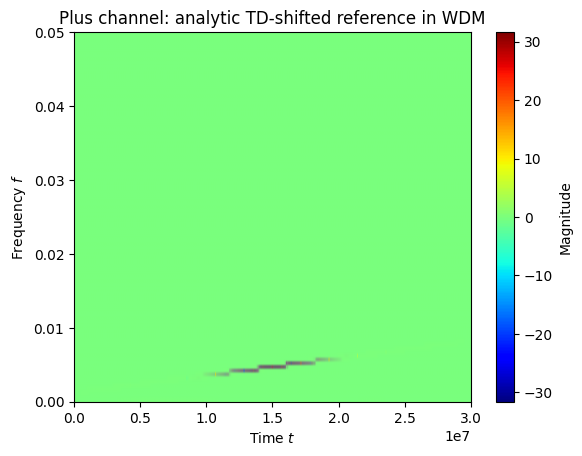

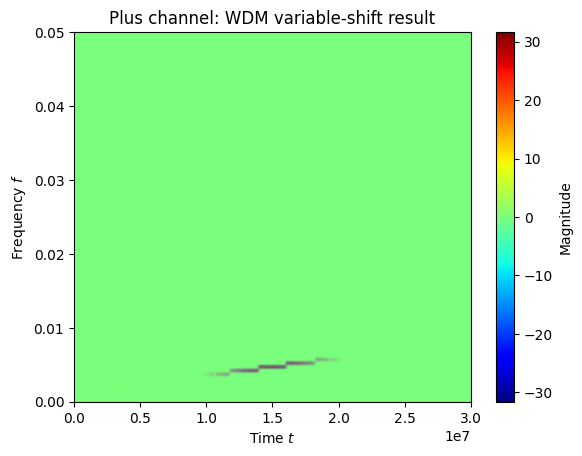

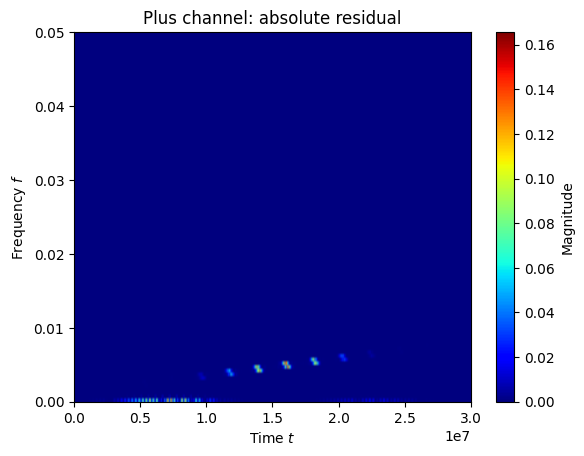

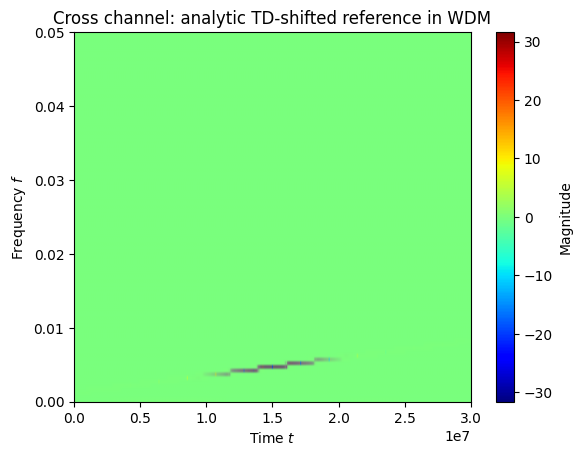

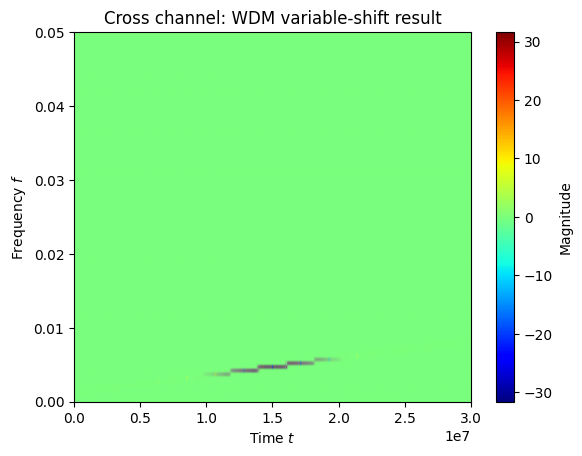

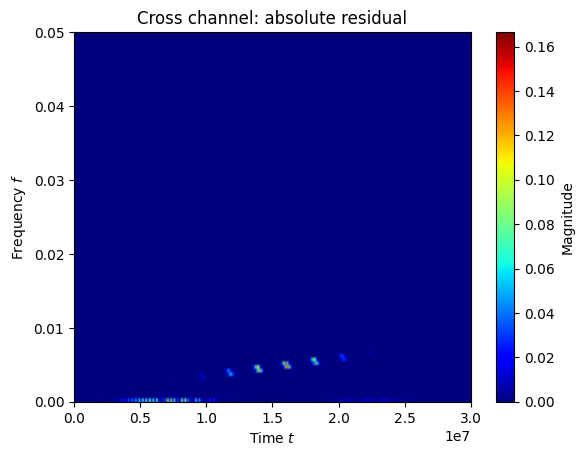

In [175]:
# --- Cell 11: WDM reference/shifted/residual plots, fixed sign convention ---
# This cell only plots plus/cross reference, shifted result, and residual.
# It does not compute or plot joint quantities.

f_max = wdm.Nf * wdm.dF

print("Plotting fixed-sign WDM comparison:")
print("  TD reference: h(t + tau)")
print("  WDM tau sign:", WDM_TAU_SIGN)
print("  f_max:", f_max)


# -------------------------------------------------------------------
# Plus channel: reference, shifted, residual
# -------------------------------------------------------------------

fig, ax = WDM.plotting.time_frequency_plot(
    wdm,
    plus_ref_fixed,
    part="real",
    scale="linear",
)
ax.set_ylim(0, f_max)
ax.set_title("Plus channel: analytic TD-shifted reference in WDM")
plt.show()

fig, ax = WDM.plotting.time_frequency_plot(
    wdm,
    plus_wdm_shifted,
    part="real",
    scale="linear",
)
ax.set_ylim(0, f_max)
ax.set_title("Plus channel: WDM variable-shift result")
plt.show()

fig, ax = WDM.plotting.time_frequency_plot(
    wdm,
    plus_ref_fixed - plus_wdm_shifted,
    part="abs",
    scale="linear",
)
ax.set_ylim(0, f_max)
ax.set_title("Plus channel: absolute residual")
plt.show()


# -------------------------------------------------------------------
# Cross channel: reference, shifted, residual
# -------------------------------------------------------------------

fig, ax = WDM.plotting.time_frequency_plot(
    wdm,
    cross_ref_fixed,
    part="real",
    scale="linear",
)
ax.set_ylim(0, f_max)
ax.set_title("Cross channel: analytic TD-shifted reference in WDM")
plt.show()

fig, ax = WDM.plotting.time_frequency_plot(
    wdm,
    cross_wdm_shifted,
    part="real",
    scale="linear",
)
ax.set_ylim(0, f_max)
ax.set_title("Cross channel: WDM variable-shift result")
plt.show()

fig, ax = WDM.plotting.time_frequency_plot(
    wdm,
    cross_ref_fixed - cross_wdm_shifted,
    part="abs",
    scale="linear",
)
ax.set_ylim(0, f_max)
ax.set_title("Cross channel: absolute residual")
plt.show()


In [176]:
# --- Cell 12: summary of standalone variable time-shift benchmark ---
# This version reports plus and cross separately. No joint mismatch is computed.

total_runtime_s = plus_runtime_s + cross_runtime_s

plus_cmp = compare_arrays(plus_test_cut, plus_ref_cut)
cross_cmp = compare_arrays(cross_test_cut, cross_ref_cut)

summary_rows = [
    {
        "channel": "plus",
        "rel_l2": plus_cmp["rel_l2"],
        "mismatch": plus_cmp["mismatch"],
        "norm_ratio": plus_cmp["norm_ratio"],
        "max_abs": plus_cmp["max_abs"],
    },
    {
        "channel": "cross",
        "rel_l2": cross_cmp["rel_l2"],
        "mismatch": cross_cmp["mismatch"],
        "norm_ratio": cross_cmp["norm_ratio"],
        "max_abs": cross_cmp["max_abs"],
    },
]

print("Standalone variable time-shift benchmark summary")
print("=" * 72)

print("\nPhysical signal:")
print("  N_phys:", pad_info["n_phys"])
print("  dt:", dt)
print("  duration_s:", pad_info["n_phys"] * dt)
print("  duration_yr:", (pad_info["n_phys"] * dt) / YEAR_SI)
print("  f_start:", f_start)
print("  f_end:", f_end)
print("  f_start / wdm.dF:", f_start / wdm.dF)
print("  f_end / wdm.dF:", f_end / wdm.dF)
print("  f_end / Nyquist:", f_end / (0.5 / dt))

print("\nPhysical delay:")
print("  tau_offset:", tau_offset)
print("  tau_amp:", tau_amp)
print("  tau_period:", tau_period)
print("  tau_period / YEAR_SI:", tau_period / YEAR_SI)
print("  tau_amp / wdm.dT:", tau_amp / wdm.dT)
print("  max delay change per WDM row:", max_delay_change_per_wdm_row)

print("\nWDM setup:")
print("  N_pad:", pad_info["n_pad"])
print("  pad_right:", pad_info["pad_right"])
print("  Nf:", Nf)
print("  q_wdm:", q_wdm)
print("  L_trunc:", L_trunc)
print("  wdm.Nt:", wdm.Nt)
print("  wdm.Nf:", wdm.Nf)
print("  wdm.dT:", wdm.dT)
print("  wdm.dF:", wdm.dF)
print("  compared WDM rows:", physical_cut_stop - physical_cut_start)
print("  compared frequency bins:", plus_ref_cut.shape[1])
print("  m=0 dropped:", True)

print("\nFixed sign convention:")
print("  TD reference: h(t + tau)")
print("  WDM input shift: -tau_wdm")
print("  TD_SIGN:", TD_SIGN)
print("  WDM_TAU_SIGN:", WDM_TAU_SIGN)

print("\nRuntime:")
print("  plus_runtime_s:", plus_runtime_s)
print("  cross_runtime_s:", cross_runtime_s)
print("  total_runtime_s:", total_runtime_s)
print("  total_runtime_ms:", 1e3 * total_runtime_s)

print("\nAccuracy:")
print_table(
    summary_rows,
    [
        "channel",
        "rel_l2",
        "mismatch",
        "norm_ratio",
        "max_abs",
    ],
)

print("\nInterpretation:")
print(
    "This benchmark uses a fixed physical chirplet and a fixed LISA-like annual "
    "sinusoidal delay, with right-padding only to make N = Nt * Nf and Nt even. "
    "The comparison is made on the original physical WDM rows, excluding the "
    "right-padded region and the low-frequency m=0 bin. Accuracy is reported "
    "separately for the plus and cross real channels."
)

Standalone variable time-shift benchmark summary

Physical signal:
  N_phys: 3000000
  dt: 10.0
  duration_s: 30000000.0
  duration_yr: 0.9506426344208685
  f_start: 0.001
  f_end: 0.008
  f_start / wdm.dF: 2.0
  f_end / wdm.dF: 16.0
  f_end / Nyquist: 0.16

Physical delay:
  tau_offset: 0.0
  tau_amp: 500.0
  tau_period: 31557600.0
  tau_period / YEAR_SI: 1.0
  tau_amp / wdm.dT: 0.5
  max delay change per WDM row: 0.09955106388286158

WDM setup:
  N_pad: 3000000
  pad_right: 0
  Nf: 100
  q_wdm: 4
  L_trunc: 20
  wdm.Nt: 30000
  wdm.Nf: 100
  wdm.dT: 1000.0
  wdm.dF: 0.0005
  compared WDM rows: 29984
  compared frequency bins: 99
  m=0 dropped: True

Fixed sign convention:
  TD reference: h(t + tau)
  WDM input shift: -tau_wdm
  TD_SIGN: 1
  WDM_TAU_SIGN: -1.0

Runtime:
  plus_runtime_s: 0.5776701659924584
  cross_runtime_s: 0.48771208300604485
  total_runtime_s: 1.0653822489985032
  total_runtime_ms: 1065.3822489985032

Accuracy:
channel  rel_l2                 mismatch              